In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [5]:
data=pd.read_csv('mall-customers.csv')
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [1]:
from sklearn.preprocessing import LabelEncoder

In [11]:
enc=LabelEncoder()
data['Genre']=enc.fit_transform(data['Genre'])

In [7]:
data.describe().round(2)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [8]:
data.drop('CustomerID',axis=1,inplace=True)

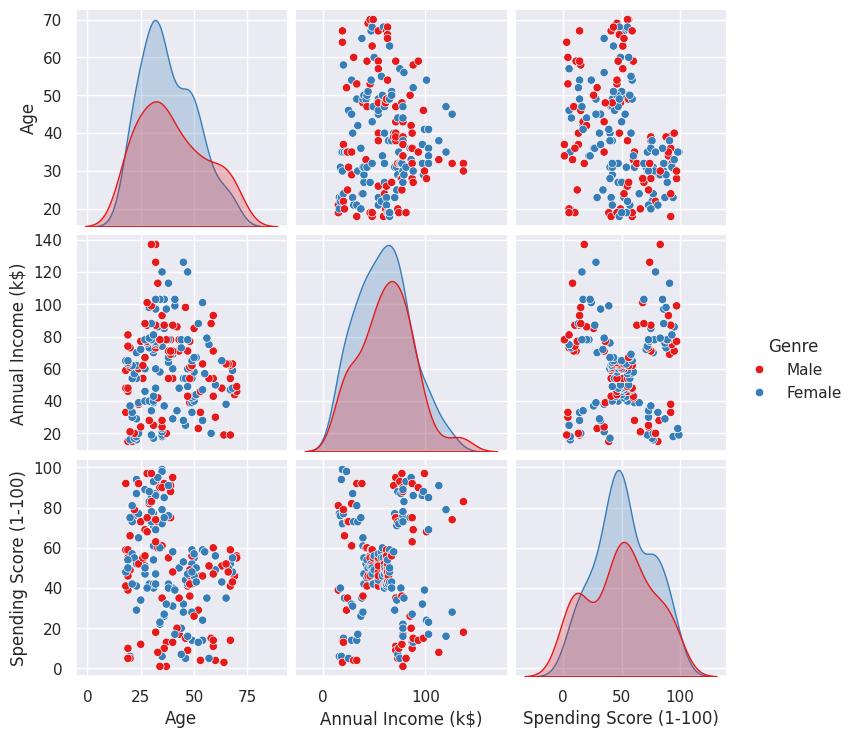

In [9]:
sns.pairplot(data,hue='Genre',palette='Set1')

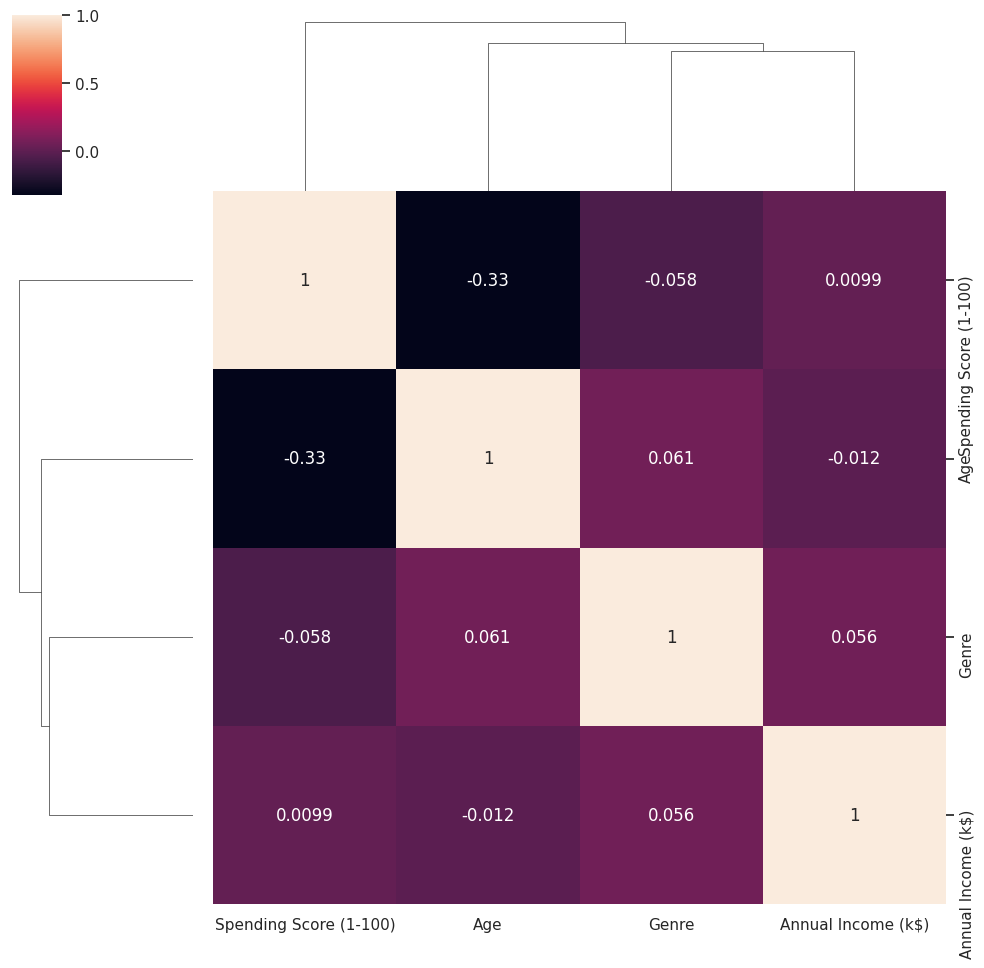

In [12]:
sns.clustermap(data.corr(),annot=True)

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

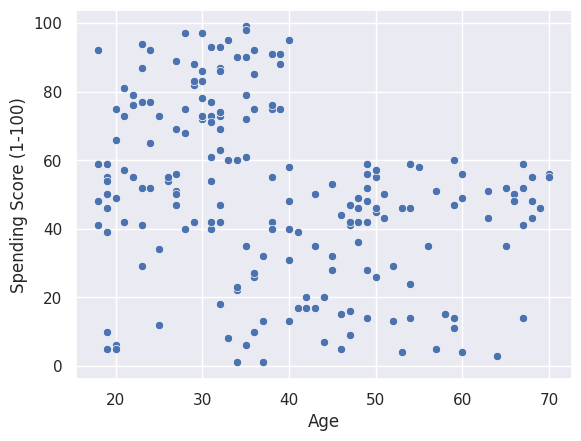

In [15]:
sns.scatterplot(data=data,x='Age',y='Spending Score (1-100)')

In [23]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 3)

In [24]:
labels = model.fit_predict(data)

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

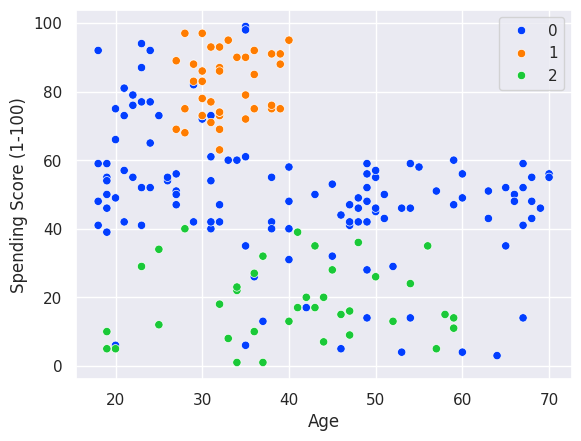

In [25]:
sns.scatterplot(data=data,x='Age',y='Spending Score (1-100)',hue=labels, palette="bright" )

In [79]:
from sklearn.cluster import DBSCAN
model2 = DBSCAN(eps=12,min_samples=5)

In [80]:
labels2 = model2.fit_predict(data)
labels2

array([-1,  0, -1,  0,  1,  0, -1, -1, -1,  0, -1, -1,  2,  0, -1,  0,  1,
        0, -1, -1,  1,  0,  2,  0,  2,  0,  1,  0,  1,  0,  2,  0,  2,  0,
        2,  0, -1,  0,  1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  3, -1,  3,  0,  3, -1,  3,  4,  3, -1,  3, -1,  3,
        4,  3, -1,  3,  4,  3, -1,  3, -1,  3, -1,  3,  4,  3,  4,  3,  4,
        3,  4,  3,  4,  3, -1,  3, -1,  3, -1,  3,  4,  3,  4,  3,  4,  3,
        4,  3,  4,  3,  4,  3,  4,  3,  4,  3, -1,  3,  4,  3, -1,  3, -1,
       -1, -1,  3, -1, -1, -1,  3, -1, -1, -1, -1, -1, -1])

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

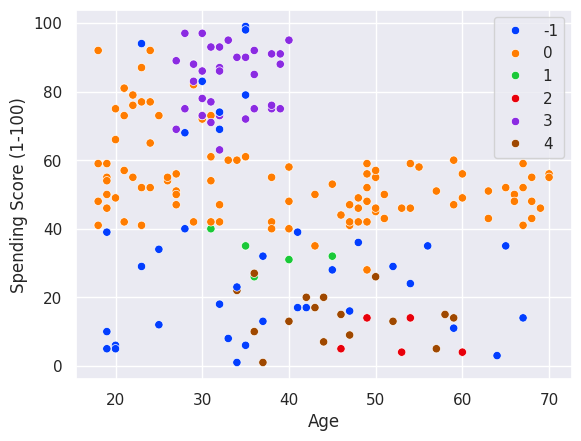

In [81]:
sns.scatterplot(data=data,x='Age',y='Spending Score (1-100)',hue=labels2,palette='bright')

In [77]:
outlier_percent = []
for eps in np.linspace(0.5,50,100):

    # Create Model
    dbscan = DBSCAN(eps=eps,min_samples=2*len(data.columns))
    dbscan.fit(data)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

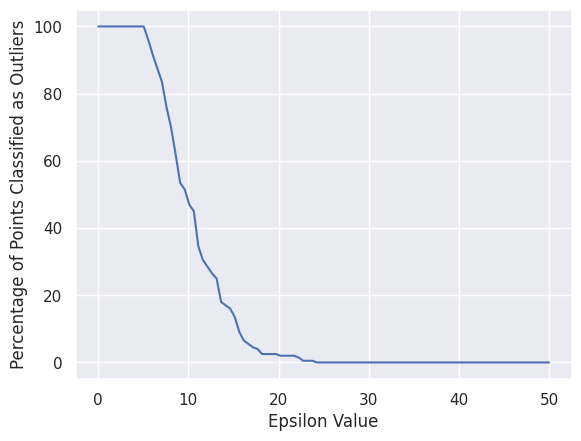

In [78]:
sns.lineplot(x=np.linspace(0,50,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

In [82]:
data['labels']=labels2
data

,Genre,Age,Annual Income (k$),Spending Score (1-100),labels
0,1,19,15,39,-1
1,1,21,15,81,0
2,0,20,16,6,-1
3,0,23,16,77,0
4,0,31,17,40,1
...,...,...,...,...,...
195,0,35,120,79,-1
196,0,45,126,28,-1
197,1,32,126,74,-1
198,1,32,137,18,-1
